In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
housing = fetch_california_housing(as_frame=True)
california_df = housing.frame

features = [col for col in california_df.columns if col != 'MedHouseVal']

X = california_df[features]
y = california_df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Dataset Dimensions (rows, cols):", california_df.shape)
print("Missing values per column:\n", california_df.isnull().sum())
print("\nFirst 3 rows of target data:")
print(y_train.head(3))

Dataset Dimensions (rows, cols): (20640, 9)
Missing values per column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

First 3 rows of target data:
14196    1.030
8267     3.821
17445    1.726
Name: MedHouseVal, dtype: float64


In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardized training features mean (approx 0):",
      round(X_train_scaled.mean(), 4))
print("Standardized training features std dev (approx 1):",
      round(X_train_scaled.std(), 4))

Standardized training features mean (approx 0): 0.0
Standardized training features std dev (approx 1): 1.0


In [3]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance Metrics")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE)      : {lr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {lr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {lr_rmse:.4f}")
print(f"R² Score                       : {lr_r2:.4f}")

Linear Regression Performance Metrics
-------------------------------------
Mean Absolute Error (MAE)      : 0.5332
Mean Squared Error (MSE)       : 0.5559
Root Mean Squared Error (RMSE) : 0.7456
R² Score                       : 0.5758


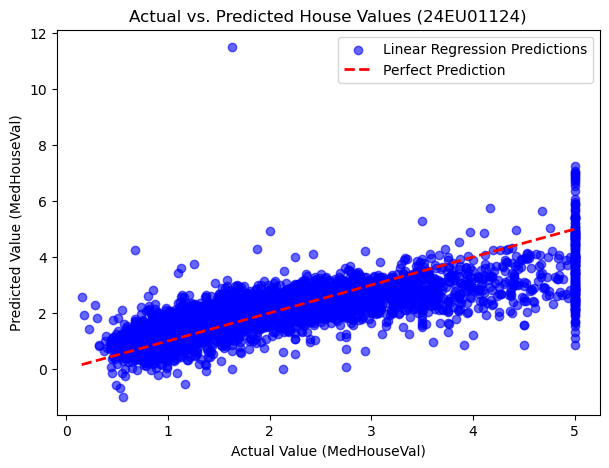

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    y_test,
    lr_predictions,
    color='blue',
    alpha=0.6,
    label='Linear Regression Predictions'
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)

plt.title("Actual vs. Predicted House Values (24EU01124)")
plt.xlabel("Actual Value (MedHouseVal)")
plt.ylabel("Predicted Value (MedHouseVal)")
plt.legend()
plt.show()

In [6]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)
svr_predictions = svr_model.predict(X_test_scaled)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("Support Vector Regression Performance Metrics")
print("---------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {svr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {svr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {svr_rmse:.4f}")
print(f"R² Score                       : {svr_r2:.4f}")

Support Vector Regression Performance Metrics
---------------------------------------------
Mean Absolute Error (MAE)      : 0.3986
Mean Squared Error (MSE)       : 0.3570
Root Mean Squared Error (RMSE) : 0.5975
R² Score                       : 0.7276


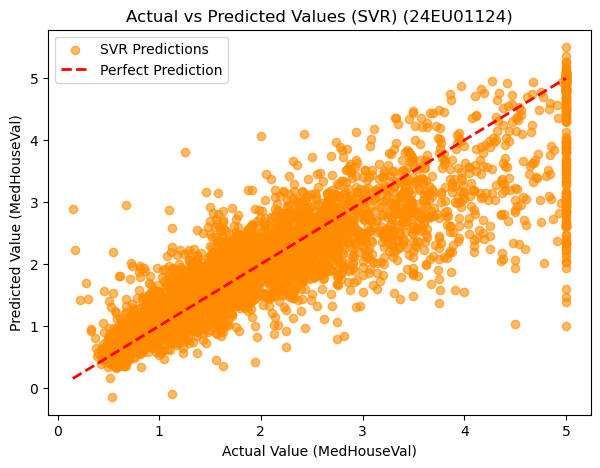

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    y_test,
    svr_predictions,
    color='darkorange',
    alpha=0.6,
    label='SVR Predictions'
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)
plt.title("Actual vs Predicted Values (SVR) (24EU01124)")
plt.xlabel("Actual Value (MedHouseVal)")
plt.ylabel("Predicted Value (MedHouseVal)")
plt.legend()
plt.show()

In [9]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression Performance Metrics")
print("--------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {dt_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {dt_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {dt_rmse:.4f}")
print(f"R² Score                       : {dt_r2:.4f}")

Decision Tree Regression Performance Metrics
--------------------------------------------
Mean Absolute Error (MAE)      : 0.4547
Mean Squared Error (MSE)       : 0.4952
Root Mean Squared Error (RMSE) : 0.7037
R² Score                       : 0.6221


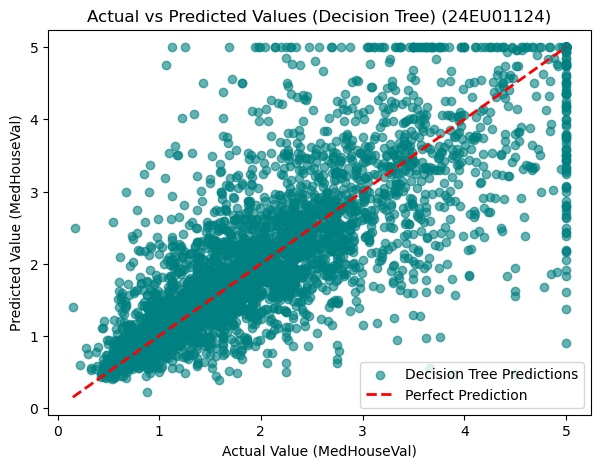

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    y_test,
    dt_predictions,
    color='teal',
    alpha=0.6,
    label='Decision Tree Predictions'
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)
plt.title("Actual vs Predicted Values (Decision Tree) (24EU01124)")
plt.xlabel("Actual Value (MedHouseVal)")
plt.ylabel("Predicted Value (MedHouseVal)")
plt.legend()
plt.show()

In [12]:
import pandas as pd

performance = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Support Vector Regression",
        "Decision Tree Regression"
    ],
    "MAE": [
        lr_mae,
        svr_mae,
        dt_mae
    ],
    "MSE": [
        lr_mse,
        svr_mse,
        dt_mse
    ],
    "RMSE": [
        lr_rmse,
        svr_rmse,
        dt_rmse
    ],
    "R² Score": [
        lr_r2,
        svr_r2,
        dt_r2
    ]
})
print("Regression Model Performance Comparison")
print(performance.to_string(index=False))

Regression Model Performance Comparison
                    Model      MAE      MSE     RMSE  R² Score
        Linear Regression 0.533200 0.555892 0.745581  0.575788
Support Vector Regression 0.398599 0.357004 0.597498  0.727563
 Decision Tree Regression 0.454679 0.495235 0.703729  0.622076
